# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
# ✅ Student Task 1: Custom AI/Deep Learning paragraph corpus
corpus = '''
deep learning is a subset of machine learning that uses neural networks with many layers
artificial intelligence enables machines to simulate human intelligence and decision making
convolutional neural networks are powerful for image recognition and computer vision tasks
recurrent neural networks process sequential data and learn temporal dependencies effectively
long short term memory networks solve the vanishing gradient problem in deep learning
gated recurrent units are efficient alternatives to lstm with fewer parameters to train
transformer models use attention mechanisms to capture global context in language tasks
natural language processing allows machines to understand and generate human language
deep neural networks learn hierarchical representations of data through multiple layers
backpropagation algorithm trains neural networks by minimizing the loss using gradient descent
attention mechanism helps models focus on relevant parts of input during sequence generation
generative adversarial networks consist of generator and discriminator networks competing together
reinforcement learning trains agents to make decisions by maximizing cumulative reward signals
dropout regularization prevents overfitting by randomly deactivating neurons during training
batch normalization accelerates deep network training by normalizing layer inputs adaptively
'''
print(corpus)


deep learning is a subset of machine learning that uses neural networks with many layers
artificial intelligence enables machines to simulate human intelligence and decision making
convolutional neural networks are powerful for image recognition and computer vision tasks
recurrent neural networks process sequential data and learn temporal dependencies effectively
long short term memory networks solve the vanishing gradient problem in deep learning
gated recurrent units are efficient alternatives to lstm with fewer parameters to train
transformer models use attention mechanisms to capture global context in language tasks
natural language processing allows machines to understand and generate human language
deep neural networks learn hierarchical representations of data through multiple layers
backpropagation algorithm trains neural networks by minimizing the loss using gradient descent
attention mechanism helps models focus on relevant parts of input during sequence generation
generativ

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
# Clean and preprocess text
import re
corpus_clean = corpus.lower()
corpus_clean = re.sub(r'[^a-z\n ]', '', corpus_clean)

# Tokenize using Keras Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus_clean])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

# Create n-gram sequences using sliding window
input_sequences = []
for line in corpus_clean.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# Pad sequences
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 127
X shape: (163, 14)
y shape: (163,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
# ✅ Student Tasks: embedding=100, hidden=128, epochs=200
rnn_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
# ✅ Student Tasks: embedding=100, hidden=128, epochs=200
lstm_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
# ✅ Student Tasks: embedding=100, hidden=128, epochs=200
gru_model = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

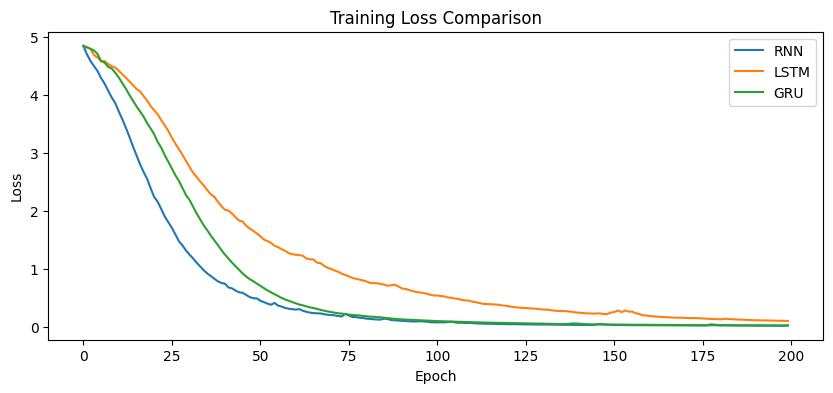

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10):
    # ✅ Student Task: generate 10 words using np.argmax() for next-word prediction
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        # Use np.argmax to pick the word with the highest predicted probability
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
# ✅ Student Task: Generate 10 words from all three models
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a subset of machine learning that uses neural networks
LSTM: deep learning is a subset of machine learning that uses neural networks


GRU : deep learning is a subset of machine learning that uses neural networks


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

### ✅ All Tasks Completed:
- ✅ Custom AI/Deep Learning corpus (15 sentences)
- ✅ Embedding size: 50 → **100**
- ✅ Hidden units: 64 → **128**
- ✅ Epochs: 100 → **200**
- ✅ Text generation: 5 → **10 words**

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**